<a href="https://colab.research.google.com/github/Vaishnavi639/GenAI/blob/main/22610081_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

config.json: 0.00B [00:00, ?B/s]

scheduler_config.json:   0%|          | 0.00/308 [00:00<?, ?B/s]

...

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

text_encoder/model.safetensors:   0%|          | 0.00/492M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


  0%|          | 0/30 [00:00<?, ?it/s]

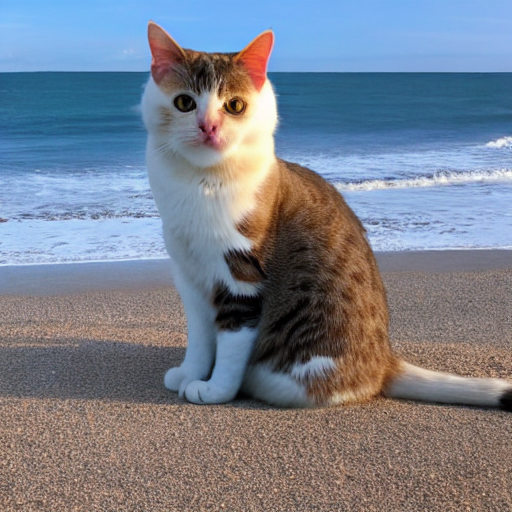

  0%|          | 0/30 [00:00<?, ?it/s]

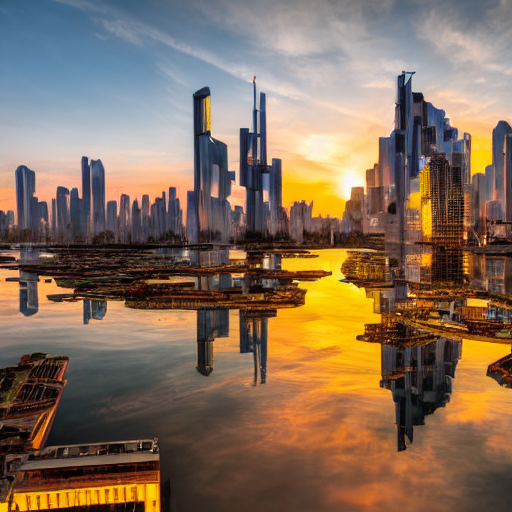

  0%|          | 0/30 [00:00<?, ?it/s]

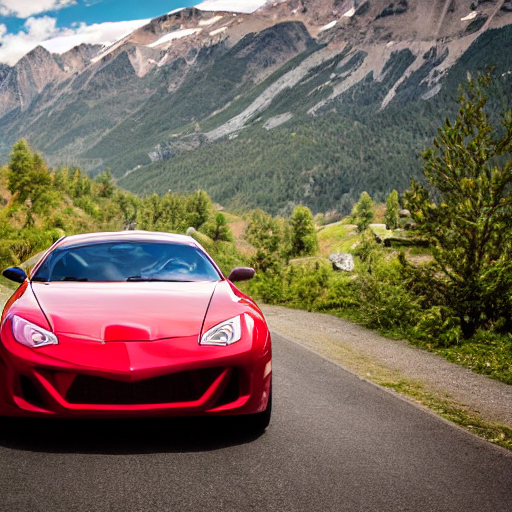

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 138MB/s] 


FID Score: -0.00


In [ ]:
# Install required packages
!pip install diffusers transformers accelerate torch torchvision scipy

import torch
from diffusers import StableDiffusionPipeline
from torchvision.transforms import functional as TF
from torchvision.models import inception_v3
import numpy as np
from scipy import linalg
from PIL import Image

# Load pre-trained Stable Diffusion model uses CLIP
device = "cuda" if torch.cuda.is_available() else "cpu"
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16 if device == "cuda" else torch.float32
)
pipe = pipe.to(device)

# Generate images from text prompts
prompts = [
    "a cat sitting on a beach",
    "a futuristic city at sunset",
    "a red sports car in the mountains"
]

generated_images = []
for prompt in prompts:
    image = pipe(prompt, num_inference_steps=30).images[0]
    generated_images.append(image)
    display(image)

# FID Score Calculation
def calculate_fid(real_images, generated_images):
    model = inception_v3(pretrained=True, transform_input=False)
    model.fc = torch.nn.Identity()
    model = model.to(device).eval()

    def get_features(images):
        features = []
        for img in images:
            img_tensor = TF.to_tensor(img.resize((299, 299))).unsqueeze(0).to(device)
            with torch.no_grad():
                feat = model(img_tensor).cpu().numpy()
            features.append(feat)
        return np.vstack(features)

    real_features = get_features(real_images)
    gen_features = get_features(generated_images)

    mu1, sigma1 = real_features.mean(axis=0), np.cov(real_features, rowvar=False)
    mu2, sigma2 = gen_features.mean(axis=0), np.cov(gen_features, rowvar=False)

    diff = mu1 - mu2
    covmean = linalg.sqrtm(sigma1.dot(sigma2))

    if np.iscomplexobj(covmean):
        covmean = covmean.real

    fid = diff.dot(diff) + np.trace(sigma1 + sigma2 - 2 * covmean)
    return fid

# For FID, you need real images. Here's an example with sample images
# Download some real images or use existing ones
sample_real_images = generated_images  # Replace with actual real images

fid_score = calculate_fid(sample_real_images, generated_images)
print(f"FID Score: {fid_score:.2f}")